# Hafta 2 — İkinci Mertebeden ADD'ler ve Doğrusal Sistemler

> **Bilim İnsanları ve Mühendisler için Diferansiyel Denklemler**  
> *Karakteristik denklemler, faz düzlemleri ve bağlı salınıcıların geometrisi.*

---

## Öğrenme Hedefleri

1. **Homojen doğrusal ikinci mertebeden ADD'leri** karakteristik denklem kullanarak çözmek
2. Zorlanmış denklemler için **parametrelerin değişimi** ve **belirsiz katsayılar** yöntemlerini uygulamak
3. Yüksek mertebeden ADD'leri **birinci mertebeden sistemlere** $\mathbf{x}' = A\mathbf{x}$ dönüştürmek
4. Dengeleri **özdeğer analizi** ile sınıflandırmak (düğüm, eyer, sarmal, merkez)
5. Sıfırdan **faz portreleri** ve **sıfır eğrileri (nullcline)** çizmek
6. **Sönümlü harmonik salınıcıyı** tüm sönüm rejimlerinde analiz etmek


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})

---

## 1. Homojen Doğrusal İkinci Mertebeden ADD'ler

Genel form:

$$a\,y'' + b\,y' + c\,y = 0$$

$y = e^{\lambda t}$ deneyin. Yerine koymak **karakteristik denklemi** verir:

$$a\lambda^2 + b\lambda + c = 0 \quad \Rightarrow \quad \lambda = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$$

| Diskriminant $\Delta = b^2 - 4ac$ | Kökler | Genel Çözüm |
|---|---|---|
| $\Delta > 0$ | $\lambda_1 \neq \lambda_2 \in \mathbb{R}$ | $y = C_1 e^{\lambda_1 t} + C_2 e^{\lambda_2 t}$ |
| $\Delta = 0$ | $\lambda_1 = \lambda_2 = \lambda$ | $y = (C_1 + C_2 t)\,e^{\lambda t}$ |
| $\Delta < 0$ | $\lambda = \alpha \pm i\beta$ | $y = e^{\alpha t}(C_1\cos\beta t + C_2\sin\beta t)$ |

### 1.1 Sönümlü Harmonik Salınıcı

$$m\,x'' + c\,x' + k\,x = 0$$

$m$'ye bölerek: $x'' + 2\gamma\,x' + \omega_0^2\,x = 0$, burada $\gamma = c/(2m)$, $\omega_0 = \sqrt{k/m}$.

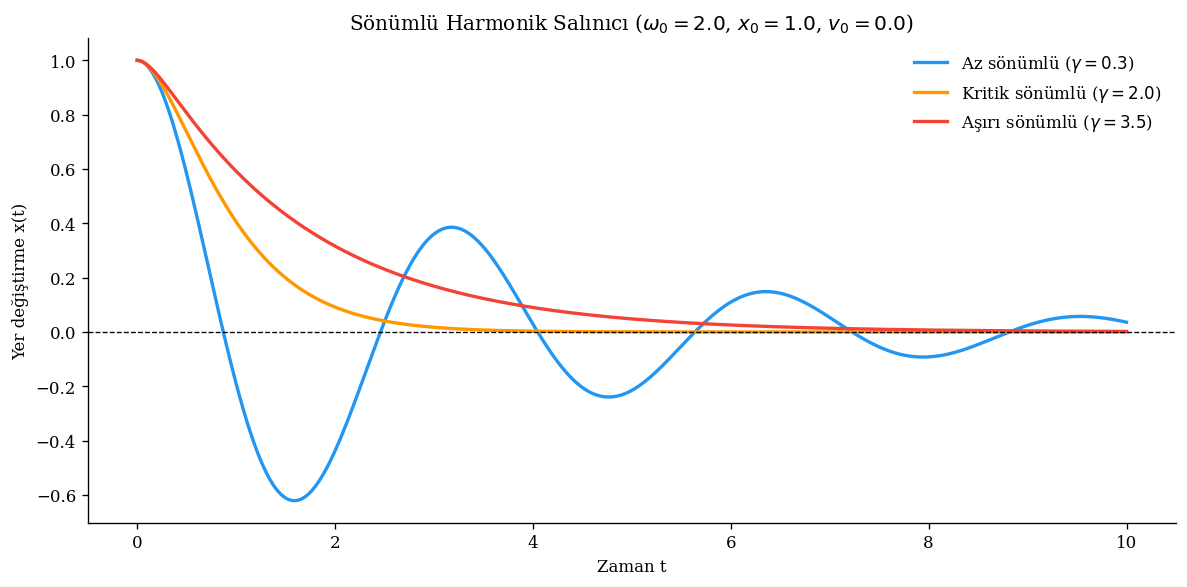

In [2]:
def sonumlu_salinici(t, x0, v0, gamma, omega0):
    """
    x'' + 2*gamma*x' + omega0^2*x = 0 denkleminin analitik çözümü.
    Üç sönüm rejimini de işler.
    """
    Delta = gamma**2 - omega0**2

    if Delta > 1e-10:   # Aşırı sönümlü
        r1 = -gamma + np.sqrt(Delta)
        r2 = -gamma - np.sqrt(Delta)
        # BK'lardan C1, C2 çöz: x(0)=x0, x'(0)=v0
        C2 = (v0 - r1 * x0) / (r2 - r1)
        C1 = x0 - C2
        return C1 * np.exp(r1 * t) + C2 * np.exp(r2 * t), 'Aşırı sönümlü'

    elif Delta < -1e-10:  # Az sönümlü
        omega_d = np.sqrt(-Delta)
        C1 = x0
        C2 = (v0 + gamma * x0) / omega_d
        return (np.exp(-gamma * t) *
                (C1 * np.cos(omega_d * t) + C2 * np.sin(omega_d * t))), 'Az sönümlü'

    else:                  # Kritik sönümlü
        C1 = x0
        C2 = v0 + gamma * x0
        return (C1 + C2 * t) * np.exp(-gamma * t), 'Kritik sönümlü'


t = np.linspace(0, 10, 1000)
omega0 = 2.0
x0, v0 = 1.0, 0.0

ayarlar = [
    (0.3, 'Az sönümlü', '#2196F3'),
    (omega0, 'Kritik sönümlü', '#FF9800'),
    (3.5, 'Aşırı sönümlü', '#F44336'),
]

fig, ax = plt.subplots(figsize=(10, 5))
for gamma, etiket, renk in ayarlar:
    y, rejim = sonumlu_salinici(t, x0, v0, gamma, omega0)
    ax.plot(t, y, color=renk, lw=2, label=f'{rejim} ($\\gamma={gamma}$)')

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Zaman t'); ax.set_ylabel('Yer değiştirme x(t)')
ax.set_title(f'Sönümlü Harmonik Salınıcı ($\\omega_0={omega0}$, $x_0={x0}$, $v_0={v0}$)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 2. Wronskian ve Doğrusal Bağımsızlık

Homojen doğrusal 2. mertebeden bir ADD'nin iki çözümü $y_1, y_2$ verildiğinde, **Wronskian**'ları:

$$W(y_1,y_2)(x) = \begin{vmatrix} y_1 & y_2 \\ y_1' & y_2' \end{vmatrix} = y_1 y_2' - y_2 y_1'$$

**Abel Teoremi:** $y_1, y_2$, $y'' + p(x)y' + q(x)y = 0$ denkleminin çözümleriyse:
$$W(x) = W(x_0)\,\exp\!\left(-\int_{x_0}^{x} p(t)\,dt\right)$$
Yani $p,q$'nun sürekli olduğu bir aralıkta $W$ **ya hep sıfır ya da hiç sıfır değildir**.

**Temel sonuç:** $y_1, y_2$ ancak ve ancak $W(y_1,y_2)(x) \neq 0$ ise bir **temel çözüm kümesi** oluşturur (yani doğrusal bağımsızdır).

**Örnek:** $y'' - 3y' + 2y = 0$ için, çözümler $y_1 = e^x$, $y_2 = e^{2x}$:
$$W = e^x \cdot 2e^{2x} - e^{2x} \cdot e^x = e^{3x} \neq 0$$

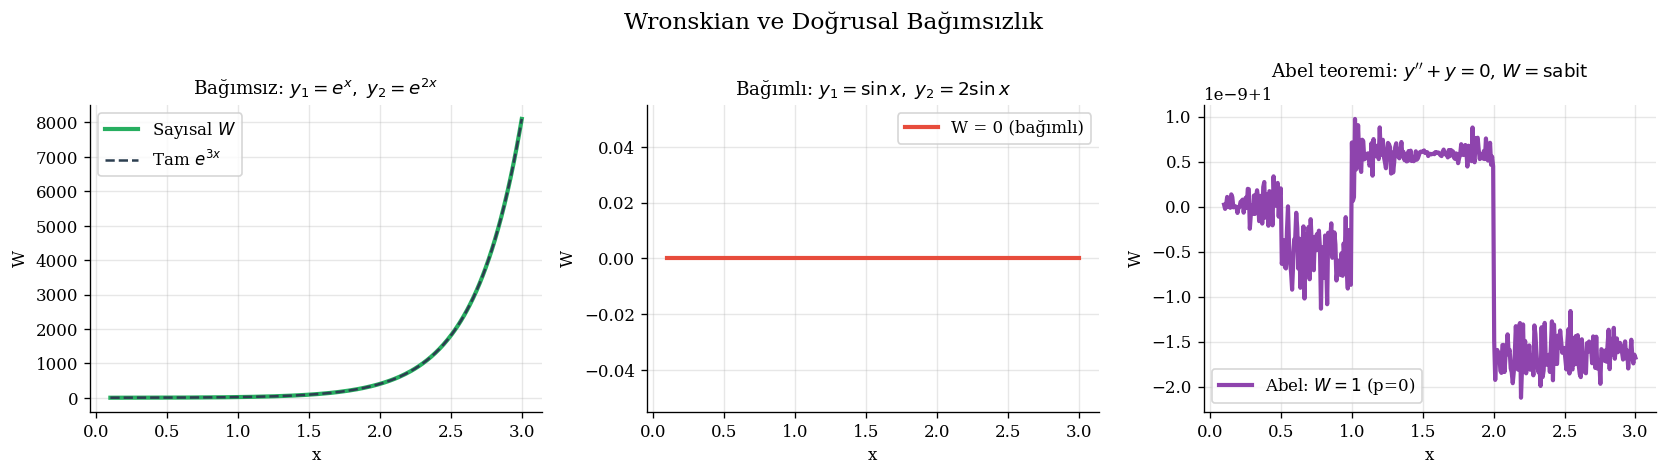

Durum A — tam Wronskian'a karşı maks hata: 1.85e-05
Durum B — maks |W| (~0 olmalı):              0.00e+00
Abel   — W aralığı (~1 olmalı):              [1.000000, 1.000000]


In [3]:
def wronskian(y1, y2, dy1, dy2):
    """Bir dizideki her noktada W(y1,y2) = y1*y2' - y2*y1' hesaplar."""
    return y1 * dy2 - y2 * dy1


def sayisal_wronskian(coz1_fonk, coz2_fonk, x_dizi, h=1e-7):
    """
    Merkezi farklar ile Wronskian'ı sayısal tahmin eder.
    coz1_fonk, coz2_fonk: çağrılabilir y(x)
    """
    y1  = coz1_fonk(x_dizi)
    y2  = coz2_fonk(x_dizi)
    dy1 = (coz1_fonk(x_dizi+h) - coz1_fonk(x_dizi-h)) / (2*h)
    dy2 = (coz2_fonk(x_dizi+h) - coz2_fonk(x_dizi-h)) / (2*h)
    return wronskian(y1, y2, dy1, dy2)


x = np.linspace(0.1, 3, 400)

# ── Durum A: Doğrusal BAĞIMSIZ — y1=e^x, y2=e^{2x} (W = e^{3x} > 0) ──
W_A = sayisal_wronskian(np.exp, lambda t: np.exp(2*t), x)
W_A_tam = np.exp(3*x)

# ── Durum B: Doğrusal BAĞIMLI — y1=sin(x), y2=2sin(x) (W = 0) ──────────
W_B = sayisal_wronskian(np.sin, lambda t: 2*np.sin(t), x)

# ── y''+y=0 için Abel teoremi doğrulaması (p=0, W=sabit) ──────────────
# Çözümler: cos(x), sin(x) — her yerde W = 1
W_cos_sin = sayisal_wronskian(np.cos, np.sin, x)

fig, eksenler = plt.subplots(1, 3, figsize=(14, 4))

eksenler[0].plot(x, W_A, lw=2.5, color='#27ae60', label='Sayısal $W$')
eksenler[0].plot(x, W_A_tam, lw=1.5, ls='--', color='#2c3e50', label=r'Tam $e^{3x}$')
eksenler[0].set_title(r'Bağımsız: $y_1=e^x,\;y_2=e^{2x}$', fontsize=11)
eksenler[0].set_xlabel('x'); eksenler[0].set_ylabel('W')
eksenler[0].legend(); eksenler[0].grid(alpha=0.3)

eksenler[1].plot(x, W_B, lw=2.5, color='#e74c3c', label='W = 0 (bağımlı)')
eksenler[1].set_title(r'Bağımlı: $y_1=\sin x,\;y_2=2\sin x$', fontsize=11)
eksenler[1].set_xlabel('x'); eksenler[1].set_ylabel('W')
eksenler[1].legend(); eksenler[1].grid(alpha=0.3)

eksenler[2].plot(x, W_cos_sin, lw=2.5, color='#8e44ad',
             label="Abel: $W=1$ (p=0)")
eksenler[2].set_title(r"Abel teoremi: $y''+y=0$, $W=\mathrm{sabit}$", fontsize=11)
eksenler[2].set_xlabel('x'); eksenler[2].set_ylabel('W')
eksenler[2].legend(); eksenler[2].grid(alpha=0.3)

fig.suptitle('Wronskian ve Doğrusal Bağımsızlık', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Durum A — tam Wronskian\'a karşı maks hata: {np.max(np.abs(W_A - W_A_tam)):.2e}')
print(f'Durum B — maks |W| (~0 olmalı):              {np.max(np.abs(W_B)):.2e}')
print(f'Abel   — W aralığı (~1 olmalı):              [{W_cos_sin.min():.6f}, {W_cos_sin.max():.6f}]')

---

## 3. Parametrelerin Değişimi

**Homojen olmayan** $y'' + p(t)y' + q(t)y = g(t)$ denklemi için, homojen denklemi çözen bir temel çift $\{y_1, y_2\}$ verildiğinde, özel çözüm:

$$y_p = -y_1\int\frac{y_2\,g}{W}\,dt + y_2\int\frac{y_1\,g}{W}\,dt$$

burada $W = y_1 y_2' - y_2 y_1'$ **Wronskian**'dır.

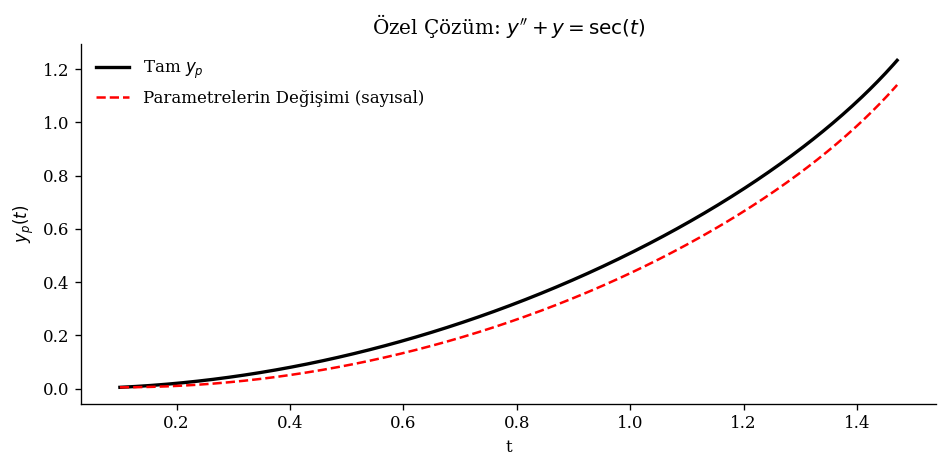

In [4]:
def parametrelerin_degisimi(y1, y2, dy1, dy2, g_fonk, t_dizi):
    """
    Kümülatif yamuk kuralı ile parametrelerin değişimi yoluyla özel çözüm hesaplar.
    y1, y2: temel çözümler (diziler)
    dy1, dy2: türevleri (diziler)
    g_fonk: zorlama fonksiyonu (çağrılabilir)
    """
    dt = t_dizi[1] - t_dizi[0]
    g = np.array([g_fonk(ti) for ti in t_dizi])
    W = y1 * dy2 - y2 * dy1                 # Wronskian

    u1 = np.cumsum(-y2 * g / W) * dt        # u1' = -y2*g/W
    u2 = np.cumsum(y1 * g / W) * dt         # u2' = y1*g/W

    return u1 * y1 + u2 * y2


# --- Örnek: y'' + y = sec(t)  üzerinde  t in [0.1, pi/2 - 0.1] ---
# Temel: y1 = cos(t), y2 = sin(t)
# Özel (bilinen): y_p = cos(t)*ln|cos(t)| + t*sin(t)

t = np.linspace(0.1, np.pi/2 - 0.1, 400)
y1  = np.cos(t);   y2  = np.sin(t)
dy1 = -np.sin(t);  dy2 = np.cos(t)
g_fonk = lambda t: 1.0 / np.cos(t)

y_p_say = parametrelerin_degisimi(y1, y2, dy1, dy2, g_fonk, t)
y_p_tam = np.cos(t) * np.log(np.abs(np.cos(t))) + t * np.sin(t)

# İntegrasyon sabiti için ayarla
y_p_say -= y_p_say[0] - y_p_tam[0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, y_p_tam, 'k-', lw=2, label='Tam $y_p$')
ax.plot(t, y_p_say, 'r--', lw=1.5, label='Parametrelerin Değişimi (sayısal)')
ax.set_xlabel('t'); ax.set_ylabel('$y_p(t)$')
ax.set_title("Özel Çözüm: $y'' + y = \\sec(t)$")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 4. Kuvvet Serisi Çözümleri

Bir ADD'nin $x_0$'da bir **olağan noktası** varsa, şu formda bir çözüm varsayarız:
$$y = \sum_{n=0}^{\infty} a_n (x-x_0)^n$$

Yerine koyup $(x-x_0)^n$'in kuvvetlerini eşleştirmek, $a_n$ için bir **rekürans bağıntısı** verir.

**Örnek — Airy denklemi:** $y'' - xy = 0$

$y = \sum a_n x^n$ yerine koymak şunu verir:
$$\sum_{n=2}^{\infty} n(n-1)a_n x^{n-2} - \sum_{n=0}^{\infty} a_n x^{n+1} = 0$$
İndisleri kaydırıp eşleştirerek: $a_{n+3} = \dfrac{a_n}{(n+3)(n+2)}$, $\;a_2 = 0$.

Bu, **iki doğrusal bağımsız seri** üretir ($a_0$ ve $a_1$ tarafından belirlenir) — Airy fonksiyonları $\mathrm{Ai}(x)$ ve $\mathrm{Bi}(x)$.

**Frobenius yöntemi:** Bir **düzenli tekil noktada** $x_0$, şunu deneyin:
$$y = x^r \sum_{n=0}^{\infty} a_n x^n$$
$r$ için **indisel denklem**, en düşük kuvvetli terimden elde edilir.

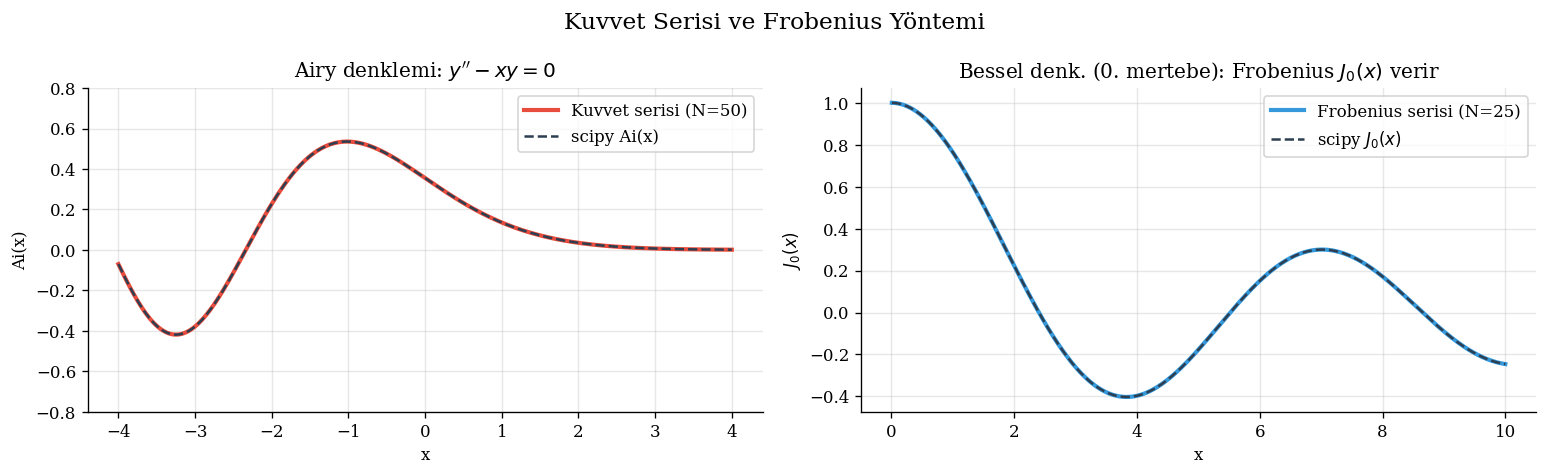

Airy  maks hata (|x|<=4): 8.78e-15
J_0   maks hata (x<=10):  1.11e-13


In [5]:
import math
def kuvvet_serisi_airy(x_dizi, a0=1.0, a1=0.0, N_terim=40):
    """
    Airy denklemi y'' - x*y = 0'ın kuvvet serisi çözümü.
    Rekürans: a_{n+3} = a_n / ((n+3)(n+2)),  a_2 = 0.

    İki bağımsız çözüm:
      y1: a0=1, a1=0  (çift-benzeri seri)
      y2: a0=0, a1=1  (tek-benzeri seri)
    Genel çözüm: y = a0*y1 + a1*y2.
    """
    # katsayı dizisini kur
    a = np.zeros(N_terim)
    a[0], a[1] = a0, a1
    # a[2] = 0 her zaman
    for n in range(N_terim - 3):
        a[n+3] = a[n] / ((n+3)*(n+2))

    # seriyi her x'te değerlendir
    sonuc = np.zeros_like(x_dizi, dtype=float)
    for n in range(N_terim):
        sonuc += a[n] * x_dizi**n
    return sonuc


def frobenius_bessel_j0(x_dizi, N_terim=30):
    """
    J_0(x) (0. mertebe Bessel fonksiyonu) için Frobenius / kuvvet serisi hesabı.
    Bessel denklemi: x^2 y'' + x y' + x^2 y = 0.
    İndisel denklem: r^2 = 0  →  r = 0.
    Rekürans (r=0): a_n = -a_{n-2} / (n^2),  n >= 2,  a_1 = 0.
    J_0(x) = sum_{m=0}^inf  (-1)^m / (m!)^2  * (x/2)^{2m}
    """
    sonuc = np.zeros_like(x_dizi, dtype=float)
    for m in range(N_terim):
        katsayi = ((-1)**m) / (float(math.factorial(m))**2)
        sonuc += katsayi * (x_dizi/2)**(2*m)
    return sonuc


from scipy.special import airy as scipy_airy, j0 as scipy_j0

x_neg = np.linspace(-4, 4, 300)       # negatif tarafta salınımlı Ai göster
x_bes = np.linspace(0.01, 10, 400)

# Airy Ai: normalize edilmiş kombinasyon a0=Ai(0), a1=Ai'(0)
from scipy.special import airy as _airy
Ai0, Aip0, _, _ = _airy(0.0)
y_seri_ai = kuvvet_serisi_airy(x_neg, a0=Ai0, a1=Aip0, N_terim=50)
Ai_tam, _, _, _ = scipy_airy(x_neg)

# Bessel J0
y_seri_j0 = frobenius_bessel_j0(x_bes, N_terim=25)
y_tam_j0  = scipy_j0(x_bes)

fig, eksenler = plt.subplots(1, 2, figsize=(13, 4))

ax = eksenler[0]
ax.plot(x_neg, y_seri_ai, lw=2.5, color='#e74c3c', label='Kuvvet serisi (N=50)')
ax.plot(x_neg, Ai_tam,    lw=1.5, ls='--', color='#2c3e50', label='scipy Ai(x)')
ax.set_title("Airy denklemi: $y'' - xy = 0$", fontsize=12)
ax.set_ylim(-0.8, 0.8); ax.set_xlabel('x'); ax.set_ylabel('Ai(x)')
ax.legend(); ax.grid(alpha=0.3)

ax = eksenler[1]
ax.plot(x_bes, y_seri_j0, lw=2.5, color='#3498db', label='Frobenius serisi (N=25)')
ax.plot(x_bes, y_tam_j0,  lw=1.5, ls='--', color='#2c3e50', label='scipy $J_0(x)$')
ax.set_title(r"Bessel denk. (0. mertebe): Frobenius $J_0(x)$ verir", fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('$J_0(x)$')
ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('Kuvvet Serisi ve Frobenius Yöntemi', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Airy  maks hata (|x|<=4): {np.max(np.abs(y_seri_ai - Ai_tam)):.2e}')
print(f'J_0   maks hata (x<=10):  {np.max(np.abs(y_seri_j0 - y_tam_j0)):.2e}')

---

## 5. ADD Sistemleri — Matris Özdeğer Yöntemi

Birinci mertebeden doğrusal bir sistem $\mathbf{x}' = A\mathbf{x}$ (sabit $A$) özayrışım yoluyla çözülür.

**Algoritma:**
1. $A$'nın özdeğerleri $\lambda_i$ ve özvektörleri $\mathbf{v}_i$'yi hesapla
2. Her çift bir temel çözüm $e^{\lambda_i t}\mathbf{v}_i$ katkısı verir
3. Genel çözüm: $\mathbf{x}(t) = \sum_i c_i e^{\lambda_i t}\mathbf{v}_i$
4. $c_i$'yi bulmak için başlangıç koşullarını uygula

**Durumlar:**

| Özdeğerler | Davranış | Faz portresi |
|-------------|----------|---------------|
| Reel, farklı | Üstel büyüme/azalma | Düğüm |
| Reel, tekrarlı | Cebirsel + üstel | Dejenere düğüm |
| Karmaşık $\alpha \pm \beta i$ | Salınımlı + üstel zarf | Sarmal / merkez |
| Saf sanal | Periyodik | Eliptik merkez |

**Temel matris:** $\Phi(t) = [\mathbf{x}_1(t)\;|\;\mathbf{x}_2(t)]$, $\Phi' = A\Phi$, $\;\Phi(0)=I$ koşullarını sağlar.

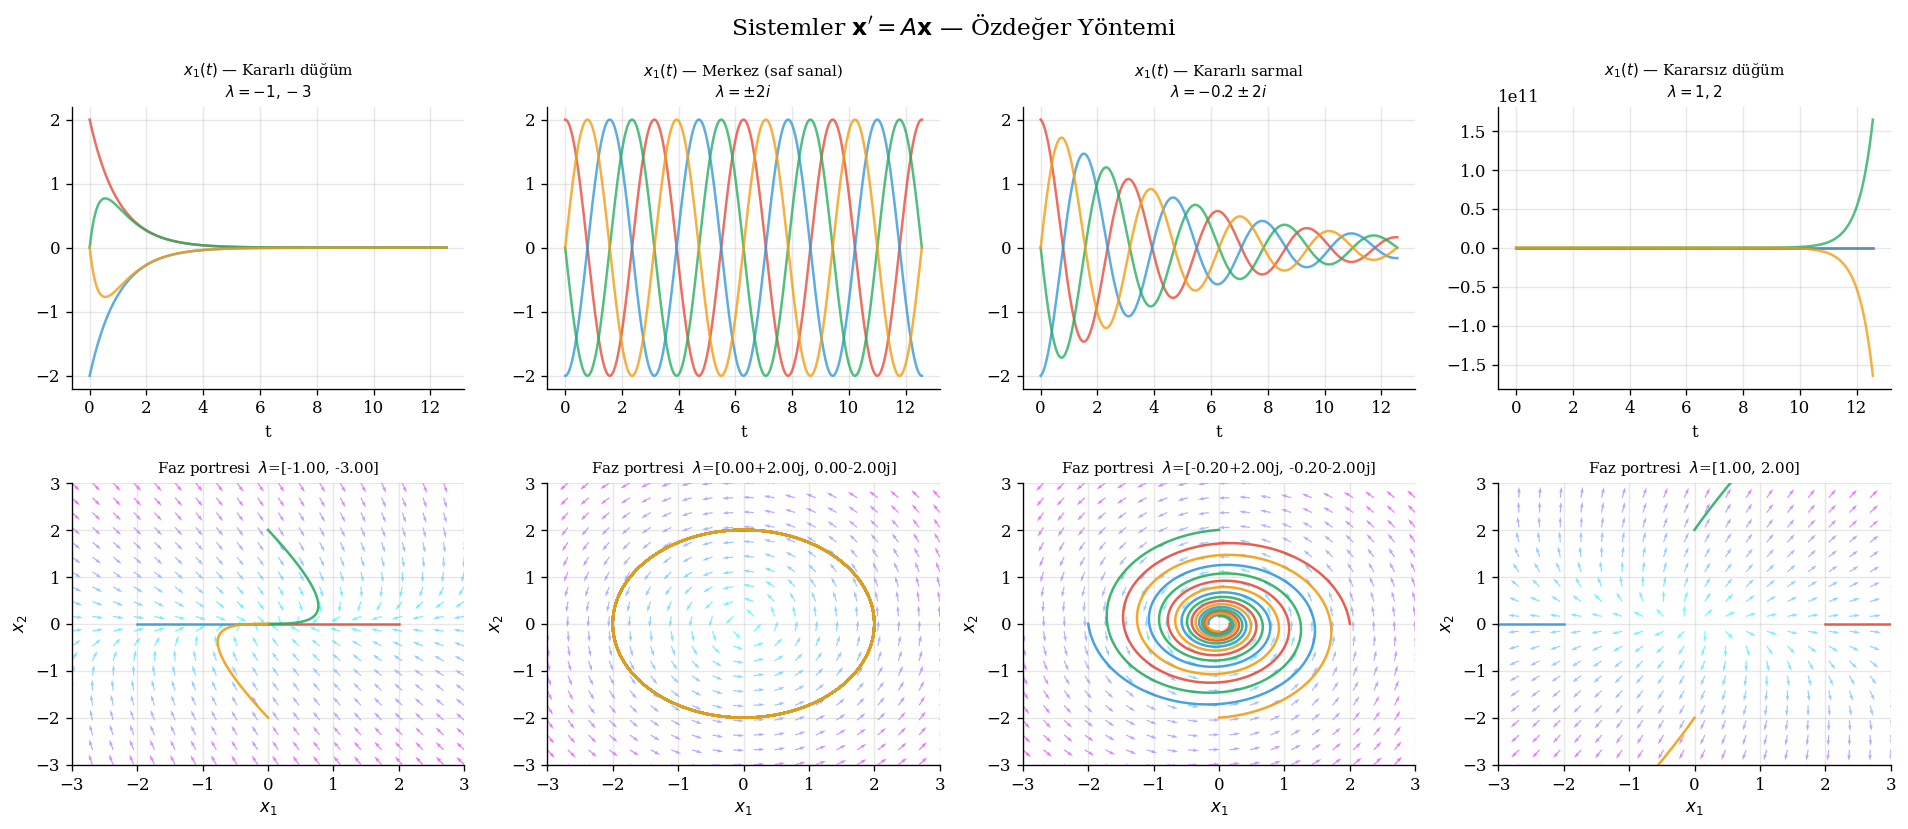

Phi(0) (I olmalı):
 [[1. 0.]
 [0. 1.]]


In [6]:
def matris_odd_cozumu(A, x0, t_dizi):
    """
    x' = A x,  x(0) = x0 denklemini özayrışım yoluyla çözer.
    Reel farklı ve karmaşık özdeğerler için çalışır.
    Reel kısmı döndürür (reel BK'lar için sanal kısım ~0).
    """
    ozdegerler, V = np.linalg.eig(A)   # V[:,i], ozdegerler[i] için özvektördür
    # katsayılar: c = V^{-1} x0
    c = np.linalg.solve(V, x0.astype(complex))
    n = len(x0)
    x = np.zeros((len(t_dizi), n), dtype=complex)
    for i in range(n):
        x += c[i] * np.exp(ozdegerler[i] * t_dizi[:, None]) * V[:, i]
    return x.real


def temel_matris(A, t_dizi, h=None):
    """
    Özayrışım kullanarak matris üstel yoluyla temel matris Phi(t)'yi kurar:
    Phi(t) = V diag(exp(lambda_i t)) V^{-1}.
    """
    ozdegerler, V = np.linalg.eig(A)
    V_ters = np.linalg.inv(V)
    Phi = np.zeros((len(t_dizi), A.shape[0], A.shape[1]), dtype=complex)
    for k, t in enumerate(t_dizi):
        D = np.diag(np.exp(ozdegerler * t))
        Phi[k] = V @ D @ V_ters
    return Phi.real


t = np.linspace(0, 4*np.pi, 800)
x0 = np.array([2.0, 0.0])

# ── Dört kanonik sistem ─────────────────────────────────────────────────
sistemler = [
    {'A': np.array([[-1., 2.],[0., -3.]]),  'etiket': 'Kararlı düğüm\n$\\lambda=-1,-3$'},
    {'A': np.array([[0., -2.],[2.,  0.]]),  'etiket': 'Merkez (saf sanal)\n$\\lambda=\\pm 2i$'},
    {'A': np.array([[-0.2,-2.],[2., -0.2]]),'etiket': 'Kararlı sarmal\n$\\lambda=-0.2\\pm2i$'},
    {'A': np.array([[1., 1.],[0.,  2.]]),   'etiket': 'Kararsız düğüm\n$\\lambda=1,2$'},
]

fig, eksenler = plt.subplots(2, 4, figsize=(16, 7))

for sutun, sis in enumerate(sistemler):
    A_sis = sis['A']
    lam = np.linalg.eigvals(A_sis)
    ax_yor  = eksenler[0, sutun]
    ax_faz = eksenler[1, sutun]

    # Birkaç BK'dan zaman-tanım yörüngeleri
    renkler = ['#e74c3c','#3498db','#27ae60','#f39c12']
    bkler = [np.array([2,0]), np.array([-2,0]), np.array([0,2]), np.array([0,-2])]
    for bk, renk_c in zip(bkler, renkler):
        yor = matris_odd_cozumu(A_sis, bk, t)
        ax_yor.plot(t, yor[:,0], color=renk_c, lw=1.5, alpha=0.8)
    ax_yor.set_title(f'$x_1(t)$ — {sis["etiket"]}', fontsize=9)
    ax_yor.set_xlabel('t'); ax_yor.grid(alpha=0.3)

    # Faz portresi
    G = 3.0
    yy, xx = np.mgrid[-G:G:20j, -G:G:20j]
    UU = A_sis[0,0]*xx + A_sis[0,1]*yy
    VV = A_sis[1,0]*xx + A_sis[1,1]*yy
    hiz = np.sqrt(UU**2 + VV**2) + 1e-9
    ax_faz.quiver(xx, yy, UU/hiz, VV/hiz, hiz, cmap='cool', alpha=0.6)
    for bk, renk_c in zip(bkler, renkler):
        yor = matris_odd_cozumu(A_sis, bk, t)
        ax_faz.plot(yor[:,0], yor[:,1], color=renk_c, lw=1.5, alpha=0.9)
    ax_faz.set_xlim(-G,G); ax_faz.set_ylim(-G,G)
    ax_faz.set_xlabel('$x_1$'); ax_faz.set_ylabel('$x_2$')
    lam_str = ', '.join(f'{v:.2f}' for v in lam)
    ax_faz.set_title(f'Faz portresi  $\\lambda$=[{lam_str}]', fontsize=9)
    ax_faz.grid(alpha=0.3)

fig.suptitle("Sistemler $\\mathbf{x}' = A\\mathbf{x}$ — Özdeğer Yöntemi", fontsize=14)
plt.tight_layout()
plt.show()

# Doğrulama: t=0'da temel matris birim matris olmalı
Phi = temel_matris(sistemler[2]['A'], np.array([0.0]))
print('Phi(0) (I olmalı):\n', np.round(Phi[0], 6))

---

## 6. Doğrusal Sistemler ve Faz Portreleri

Herhangi bir $n$. mertebeden ADD, birinci mertebeden $\mathbf{x}' = A\mathbf{x}$ sistemi olarak yazılabilir.

2B sistem için, $A$'nın **özdeğerleri** $\lambda_1, \lambda_2$ topolojiyi belirler:

| Özdeğer türü | Denge türü | Kararlı mı? |
|---|---|---|
| Her ikisi reel, aynı işaret | Düğüm (kararlı/kararsız) | $\text{Re}(\lambda) < 0$ |
| Her ikisi reel, zıt işaret | Eyer | Asla |
| Karmaşık eşlenikler $\alpha \pm i\beta$ | Sarmal | $\alpha < 0$ |
| Saf sanal $\pm i\beta$ | Merkez | Nötr kararlı |

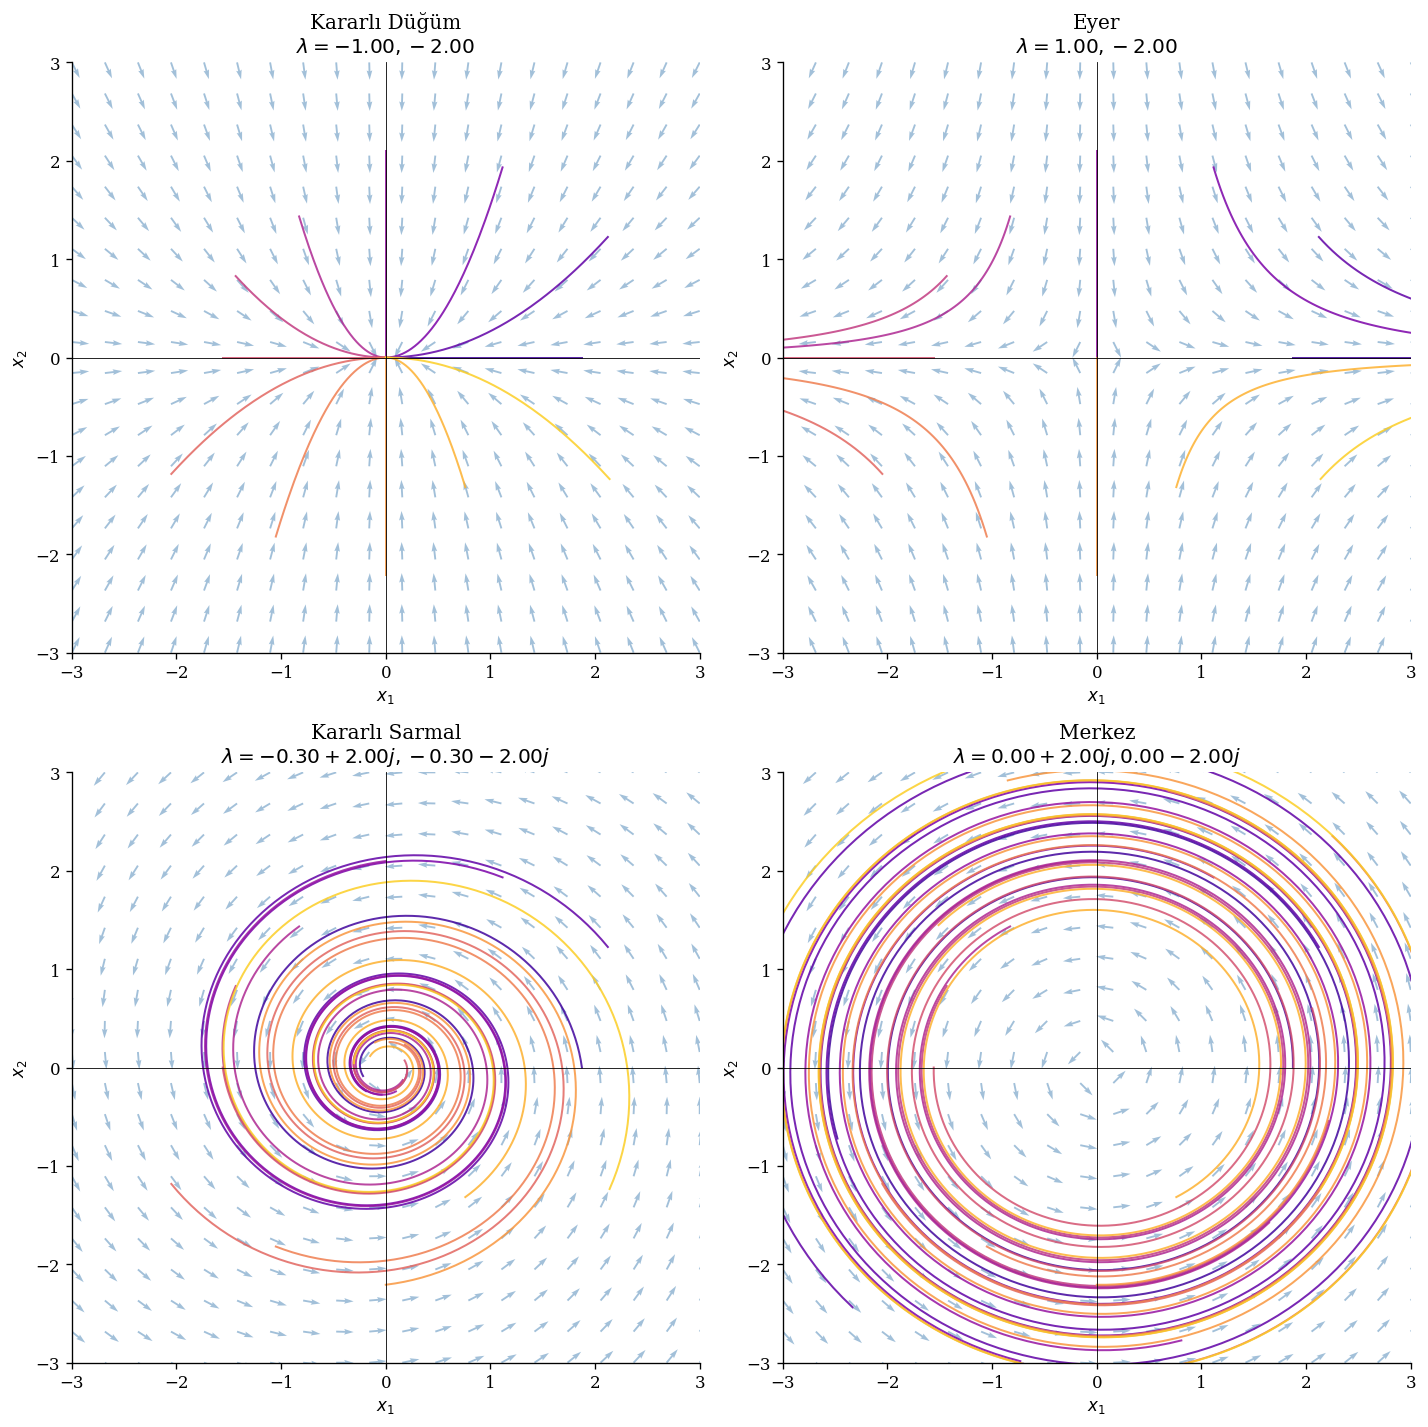

In [7]:
def faz_portresi(A, x_araligi=(-3, 3), y_araligi=(-3, 3), n=20, ax=None, baslik=''):
    """Izgara üzerinde vektör alanını hesaplayarak x' = Ax için faz portresi çizer."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    x_degerleri = np.linspace(*x_araligi, n)
    y_degerleri = np.linspace(*y_araligi, n)
    X, Y = np.meshgrid(x_degerleri, y_degerleri)
    UV = A @ np.array([X.ravel(), Y.ravel()])
    U, V = UV[0].reshape(n, n), UV[1].reshape(n, n)

    norm = np.sqrt(U**2 + V**2) + 1e-12
    ax.quiver(X, Y, U/norm, V/norm, alpha=0.5, color='steelblue',
              width=0.003, headwidth=3)

    # İleri Euler ile birkaç yörünge bindir
    np.random.seed(42)
    r = np.random.uniform(1.5, 2.5, 12)
    theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
    bkler = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

    renkler = cm.plasma(np.linspace(0.1, 0.9, len(bkler)))
    dt = 0.02
    N_adim = 400

    for bk, c in zip(bkler, renkler):
        yor = [bk.copy()]
        durum = bk.copy()
        for _ in range(N_adim):
            durum = durum + dt * (A @ durum)
            if np.linalg.norm(durum) > 6:
                break
            yor.append(durum.copy())
        yor = np.array(yor)
        ax.plot(yor[:, 0], yor[:, 1], color=c, lw=1.2, alpha=0.85)

    ozdeg = np.linalg.eigvals(A)
    ax.set_xlim(*x_araligi); ax.set_ylim(*y_araligi)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(f'{baslik}\n$\\lambda = {ozdeg[0]:.2f}, {ozdeg[1]:.2f}$')
    return ax


# Dört kanonik denge türü
durumlar = [
    (np.array([[-1, 0], [0, -2]]), 'Kararlı Düğüm'),
    (np.array([[1, 0], [0, -2]]), 'Eyer'),
    (np.array([[-0.3, -2], [2, -0.3]]), 'Kararlı Sarmal'),
    (np.array([[0, -2], [2, 0]]), 'Merkez'),
]

fig, eksenler = plt.subplots(2, 2, figsize=(12, 12))
for ax, (A, baslik) in zip(eksenler.ravel(), durumlar):
    faz_portresi(A, ax=ax, baslik=baslik)

plt.tight_layout(); plt.show()

---

## 7. Zorlanmış Salınıcılarda Rezonans

Zorlanmış salınıcı:

$$x'' + 2\gamma\,x' + \omega_0^2\,x = F_0\cos(\omega t)$$

bir özel çözüme $x_p = A(\omega)\cos(\omega t - \phi)$ sahiptir; burada **genlik tepkisi**:

$$A(\omega) = \frac{F_0}{\sqrt{(\omega_0^2 - \omega^2)^2 + 4\gamma^2\omega^2}}$$

**Rezonans**, $\omega = \omega_r = \sqrt{\omega_0^2 - 2\gamma^2}$ olduğunda oluşur.

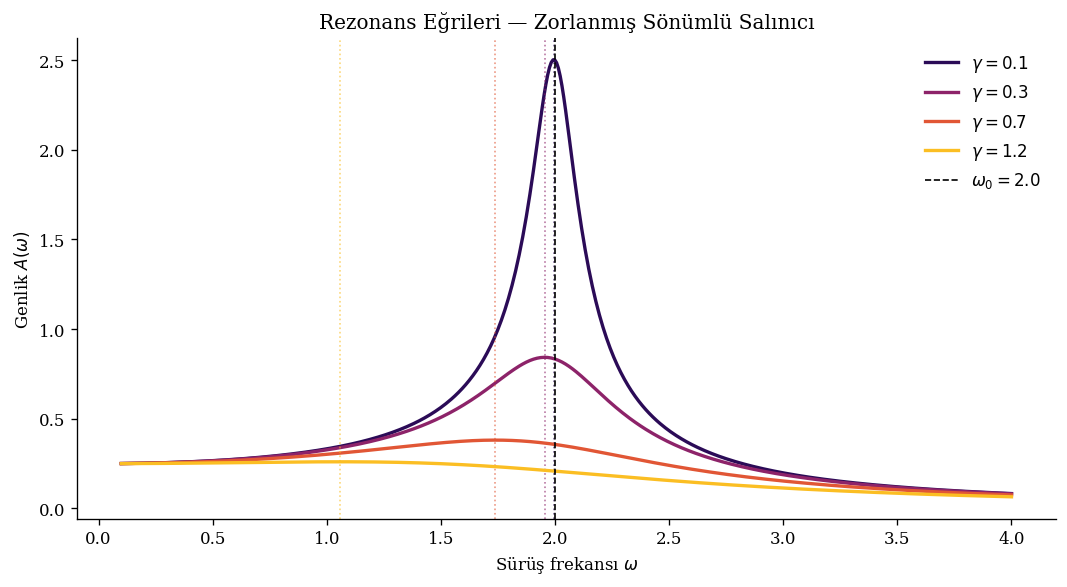

In [8]:
omega_surus = np.linspace(0.1, 4, 500)
omega0 = 2.0
F0 = 1.0
gammalar = [0.1, 0.3, 0.7, 1.2]

fig, ax = plt.subplots(figsize=(9, 5))
renkler = cm.inferno(np.linspace(0.15, 0.85, len(gammalar)))

for gamma, c in zip(gammalar, renkler):
    A_omega = F0 / np.sqrt((omega0**2 - omega_surus**2)**2 + 4*gamma**2*omega_surus**2)
    omega_r = np.sqrt(max(omega0**2 - 2*gamma**2, 0))
    ax.plot(omega_surus, A_omega, color=c, lw=2, label=f'$\\gamma={gamma}$')
    if omega_r > 0:
        ax.axvline(omega_r, color=c, ls=':', lw=1, alpha=0.6)

ax.axvline(omega0, color='k', ls='--', lw=1, label=f'$\\omega_0={omega0}$')
ax.set_xlabel('Sürüş frekansı $\\omega$')
ax.set_ylabel('Genlik $A(\\omega)$')
ax.set_title('Rezonans Eğrileri — Zorlanmış Sönümlü Salınıcı')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 8. Alıştırmalar

1. **(Karakteristik denklem)** $y'' - 5y' + 6y = 0$ denklemini $y(0) = 1$, $y'(0) = 0$ ile çözün. İleri Euler ile sayısal olarak doğrulayın.

2. **(Tekrarlı kökler)** $y'' - 4y' + 4y = 0$ denklemini çözün ve iki doğrusal bağımsız çözümün neden $t$ çarpanı gerektirdiğini açıklayın.

3. **(Parametrelerin Değişimi)** $y'' + 4y = \tan(2t)$ denklemini parametrelerin değişimi ile çözün. $y_h + y_p$'yi çizin.

4. **(Faz portresi)** $A = \begin{pmatrix}1 & -4\\1 & -1\end{pmatrix}$ matrisinin dengesini sınıflandırın ve faz portresini çizin.

5. **(Doğrusal olmayan önizleme)** Sarkaç $\theta'' + \sin\theta = 0$'ı sağlar. $\theta^* = 0$ ve $\theta^* = \pi$ etrafında doğrusallaştırın, her dengeyi sınıflandırın ve doğrusal faz portresini gerçek doğrusal olmayanla karşılaştırın.

6. **(Wronskian)** $y'' + 4y = 0$ denklemi için $\cos 2x$ ve $\sin 2x$ çözümleriyle $W$'yi analitik olarak hesaplayın ve Abel teoremini doğrulayın (dikkat: $p(x)=0$).

7. **(Kuvvet serisi)** $y'' + xy' + y = 0$ denkleminin $x_0=0$ etrafındaki kuvvet serisi çözümünün ilk 6 sıfır olmayan terimini türetin ve sayısal bir RK4 çözümüne karşı çizin.

8. **(Matris sistemi)** $\mathbf{x}' = \begin{pmatrix}2&1\\0&3\end{pmatrix}\mathbf{x}$ denklemini $\mathbf{x}(0)=(1,1)^T$ ile `matris_odd_cozumu` kullanarak çözün. $\mathbf{x}(1)$'i analitik olarak doğrulayın.
